In [1]:
import ImtaTURB as imta
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Aplicación de fórmulas según B. Mutlu [2006]
# Hydrodynamics Around Cylindrical Structures (1.1)
D = 0.05 # Diametro de cilindro en metros
U = 0.194 # Velocidad en m/s
nu = 1.004e-6 # Viscocidad en m^2/s
No_Re = (D*U)/nu
print("(1.1) Re =", No_Re)
print("Subcrítico. Esteña completamente turbulenta. Separacion de la capa límite laminar.")

(1.1) Re = 9661.354581673306
Subcrítico. Esteña completamente turbulenta. Separacion de la capa límite laminar.


In [3]:
# Carga de archivos de simulación numérica
file_U = "Datos/OpenFOAM/20_cm/U"
file_p = "Datos/OpenFOAM/20_cm/p.csv"

In [4]:
df = pd.read_csv(file_p, sep=r',')
# Creando copia del DataFrame para evitar modificar el original
pk = df.copy()
# Se ignoran el primeros 50 segundos de dato (Arranque del modelo LES)
pk = pk.iloc[5000:-1, :]
# Conversión de pk a p_cinematica
rho = 1000.00 # Densidad del fluido (kg/m^3)
p_est = pk * rho # Presión estática (Pa)
p_est_med = p_est.mean()  # Media de la presión estática
# Imprimiendo presiones medias para la probe
print(p_est_med)

0            124995.000000
Probe_0           2.818816
Probe_1           2.817734
Probe_2           2.816843
Probe_3           8.052115
                 ...      
Probe_163        -9.040293
Probe_164        -9.040293
Probe_165        -9.455714
Probe_166        -9.455714
Probe_167        -9.050810
Length: 169, dtype: float64


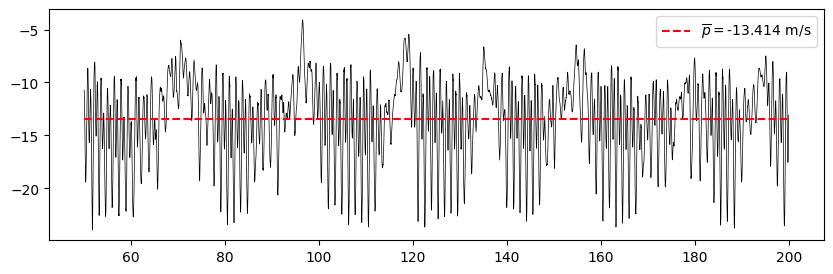

In [5]:
p = 25 # Inserte numero de probe que se desea graficar
loc = 'Probe_'+ str(p) + str('')
presiones = p_est[loc]
plt.figure(figsize=(10,3))
plt.plot(p_est['0']/1000, presiones, linewidth=0.5, color='k')
plt.hlines(presiones.mean(), 
            p_est['0'].iloc[0]/1000,
            p_est['0'].iloc[-1]/1000,
            colors='r',
            linestyles='dashed',
            label=r'$\overline{p}=$' + f'{presiones.mean():.3f} m/s')
plt.legend(loc='upper right')

In [13]:
U_probes, tiempo, coords, frecuencia = imta.cargar_U_OpenFOAM(file_U)

c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Se extrajeron 168 probes.
Tiempo inicial: 0.00 s, tiempo final: 200.00 s
Duración de la muestra: 200.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


In [ ]:
print(U_probes[0])

              Ux        Uy        Uz
0.00    0.194000  0.000000  0.000000
0.01    0.183683 -0.016928  0.000147
0.02    0.182535 -0.012971  0.000109
0.03    0.181514 -0.009475  0.000076
0.04    0.180625 -0.006457  0.000049
...          ...       ...       ...
199.96  0.177159  0.000004 -0.000013
199.97  0.177159  0.000004 -0.000011
199.98  0.177159  0.000004 -0.000010
199.99  0.177159  0.000004 -0.000009
200.00  0.177159  0.000004 -0.000007

[20001 rows x 3 columns]


Coordenadas probe 25: (0.42462, 0.1, 0.30434)


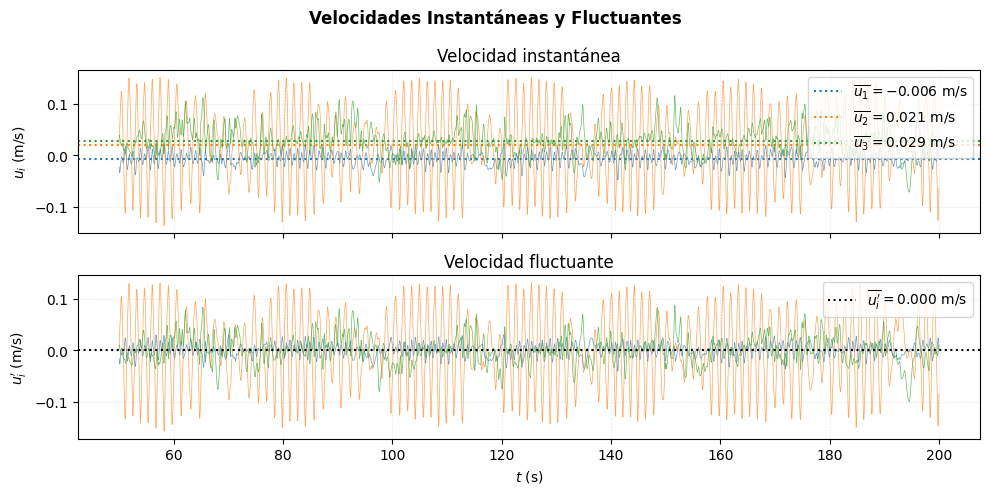

In [7]:
# Seleccionar un probe para análisis
probe = p
print(f"Coordenadas probe {probe}: {coords[probe]}")

# Tiempo de análisis
u1, u2, u3, tiempo, dfp_filt = imta.recortar_tiempo(U_probes, probe,
                                                    inicio= 50.0)

# Velocidades fluctuantes
u1_fluc, fig1 = imta.fluctuante(u1, tiempo=tiempo, plot=False, titulo='Velocidad u1')
u2_fluc, fig2 = imta.fluctuante(u2, tiempo=tiempo, plot=False, titulo='Velocidad u2')
u3_fluc, fig3 = imta.fluctuante(u3, tiempo=tiempo, plot=False, titulo='Velocidad u3')
imta.plot_ui(tiempo, u1_fluc, u2_fluc, u3_fluc,
             etiquetas=('u_1', 'u_2', 'u_3'));

In [8]:
print(U_probes)

{0:               Ux        Uy        Uz
0.00    0.194000  0.000000  0.000000
0.01    0.183683 -0.016928  0.000147
0.02    0.182535 -0.012971  0.000109
0.03    0.181514 -0.009475  0.000076
0.04    0.180625 -0.006457  0.000049
...          ...       ...       ...
199.96  0.177159  0.000004 -0.000013
199.97  0.177159  0.000004 -0.000011
199.98  0.177159  0.000004 -0.000010
199.99  0.177159  0.000004 -0.000009
200.00  0.177159  0.000004 -0.000007

[20001 rows x 3 columns], 1:               Ux        Uy        Uz
0.00    0.194000  0.000000  0.000000
0.01    0.184732 -0.016205  0.000150
0.02    0.183732 -0.012390  0.000110
0.03    0.182838 -0.009016  0.000077
0.04    0.182058 -0.006110  0.000049
...          ...       ...       ...
199.96  0.178977  0.000003 -0.000013
199.97  0.178977  0.000003 -0.000011
199.98  0.178977  0.000003 -0.000010
199.99  0.178977  0.000003 -0.000008
200.00  0.178977  0.000003 -0.000007

[20001 rows x 3 columns], 2:               Ux        Uy        Uz
0.00    0.1

In [9]:
# Tau = mu (du/dy)


In [10]:
# Tau = mu (du/dy)
p1 = 62 # Probe más alejada a la pared 
p2 = 26 # Probe pegada a la pared

In [11]:
# Obtener coordenadas de las probes 25 y 61
# coords[i] contiene (x, y, z) para la probe i
coord_25 = coords[p2]
coord_61 = coords[p1]

# Extraer componentes x y z
x2, y2, z2 = coord_25
x1, y1, z1 = coord_61

# Calcular distancia en el plano xz (ignorando y)
distancia_xz = np.sqrt((x2 - x1)**2 + (z2 - z1)**2)

print(f"Coordenadas probe 25: x={x1:.4f}, y={y1:.4f}, z={z1:.4f}")
print(f"Coordenadas probe 61: x={x2:.4f}, y={y2:.4f}, z={z2:.4f}")
print(f"\nDistancia en plano xz: {distancia_xz:.4f} m")

# Si también quieres las diferencias individuales:
print(f"\nDiferencia en x: {abs(x2-x1):.4f} m")
print(f"Diferencia en z: {abs(z2-z1):.4f} m")

Coordenadas probe 25: x=0.4291, y=0.1000, z=0.3106
Coordenadas probe 61: x=0.4235, y=0.1000, z=0.3085

Distancia en plano xz: 0.0060 m

Diferencia en x: 0.0056 m
Diferencia en z: 0.0020 m
